In [2]:
import numpy as np
import statistics
import seaborn as sns
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_digits
import project_utils
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, accuracy_score

In [43]:
# Load dataset
df=pd.read_csv('Listings.csv',encoding="latin1")

/tmp/ipykernel_332812/2375660349.py:2: DtypeWarning: Columns (5,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('Listings.csv',encoding="latin1")


In [ ]:

features = [
    "price",
    "accommodates",
    "bedrooms",
    "minimum_nights",
    "maximum_nights",
    "host_total_listings_count",
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "latitude",
    "longitude",
]


print(df[features].describe())

/tmp/ipykernel_329272/2734744417.py:1: DtypeWarning: Columns (5,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('Listings.csv',encoding="latin1")


               price   accommodates       bedrooms  minimum_nights  \
count  279712.000000  279712.000000  250277.000000   279712.000000   
mean      608.792737       3.288736       1.515509        8.050967   
std      3441.826611       2.133379       1.153080       31.518946   
min         0.000000       0.000000       1.000000        1.000000   
25%        75.000000       2.000000       1.000000        1.000000   
50%       150.000000       2.000000       1.000000        2.000000   
75%       474.000000       4.000000       2.000000        5.000000   
max    625216.000000      16.000000      50.000000     9999.000000   

       maximum_nights  host_total_listings_count  review_scores_rating  \
count    2.797120e+05              279547.000000         188307.000000   
mean     2.755860e+04                  24.581612             93.405195   
std      7.282875e+06                 284.041143             10.070437   
min      1.000000e+00                   0.000000             20.000000   

In [21]:

X=df[features].dropna()
X=X[X['price']> 1000]

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)


In [22]:
def plot_correlation_circle(initial_variables, new_variables, feature_names,c1=0,c2=1, pc_labels=['PC1', 'PC2']):
    plt.figure(figsize=(8, 8))
    
    # Tracer un cercle unité
    circle = plt.Circle((0, 0), 1, color='gray', fill=False)
    plt.gca().add_artist(circle)
    
    # Tracer les flèches (correlations des variables)
    for i in range(len(feature_names)):
        x=np.corrcoef(new_variables[:,c1],initial_variables[:,i])[0,1]
        y=np.corrcoef(new_variables[:,c2],initial_variables[:,i])[0,1]
        plt.arrow(0, 0, x, y, head_width=0.05, head_length=0.001, fc='red', ec='red')
        plt.text(x * 1.1, y * 1.1, feature_names[i], color='black', ha='center', va='center')
    
    # Ajustements esthétiques
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    plt.xlabel(pc_labels[0])
    plt.ylabel(pc_labels[1])
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.title('Cercle de corrélation')
    plt.show()

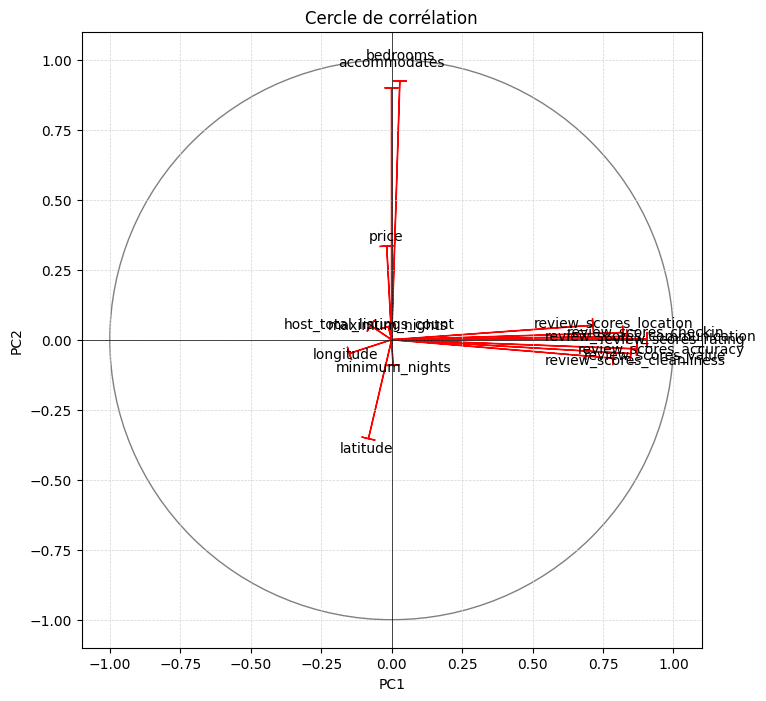

In [23]:
pca=PCA() #n_components=2)
X_pca=pca.fit_transform(X_scaled)

plot_correlation_circle(X_scaled,X_pca,features)


In [25]:
from sklearn.metrics.pairwise import cosine_similarity

price = X['prices']
sims = []
for comp in pca.components_:
    sims.append(cosine_similarity(price, comp))

print()

KeyError: 'prices'

In [9]:
feature_names = features
price_idx = feature_names.index("price")

# -------------------------
# 5. Extract loadings
# -------------------------
loadings = []

for i, comp in enumerate(pca.components_):
    loading = comp[price_idx]
    loadings.append((i, loading))

# -------------------------
# 6. Sort by importance
# -------------------------
sorted_loadings = sorted(loadings, key=lambda x: abs(x[1]), reverse=True)

# -------------------------
# 7. Print results
# -------------------------
print("Components most related to PRICE:\n")

for i, val in sorted_loadings:
    print(f"Component {i+1}: loading = {val:.4f}")

NameError: name 'pca' is not defined

## **Unsupervised part of project**

In [6]:
# Data pre-processing
from project_utils import features

# Ensure we only use paris listings
df_paris = df[df['city'] == 'Paris'].copy()

# Inlcude amenities for computing amenity score
df_cleaned = df_paris[features + ['amenities']].dropna(subset=['review_scores_rating'])

# Impute 'bedrooms' and 'host_count' with the median
df_cleaned['bedrooms'] = df_cleaned['bedrooms'].fillna(df_cleaned['bedrooms'].median())
df_cleaned['host_total_listings_count'] = df_cleaned['host_total_listings_count'].fillna(df_cleaned['host_total_listings_count'].median())

# Uncomment to perform checks
# print(df_cleaned[features].isnull().sum())
df_cleaned = df_cleaned.dropna()
# print(len(df_cleaned))

In [7]:
from project_utils import add_amenity_scores

add_amenity_scores(df_cleaned)

print(df_cleaned[['amenities', 'amenity_expert_score']].head())

# Add amenity score to dataframe
df_cleaned = df_cleaned.drop(columns=['amenities'])

                                           amenities  amenity_expert_score
0  ["Heating", "Kitchen", "Washer", "Wifi", "Long...                    39
1  ["Shampoo", "Heating", "Kitchen", "Essentials"...                    52
2  ["Heating", "TV", "Kitchen", "Washer", "Wifi",...                    43
3  ["Heating", "TV", "Kitchen", "Wifi", "Long ter...                    35
4  ["Heating", "TV", "Kitchen", "Essentials", "Ha...                    75


In [ ]:
# Features for clustering (excluding price)
cluster_features = [f for f in features if f != "price"] + ['amenity_expert_score']

X = df_cleaned[cluster_features]

# Scale data for good clustering and PCA decomposition
scaler=StandardScaler()
X_scaled =scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)


['accommodates', 'bedrooms', 'minimum_nights', 'maximum_nights', 'host_total_listings_count', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'latitude', 'longitude', 'amenity_expert_score']


PCA()

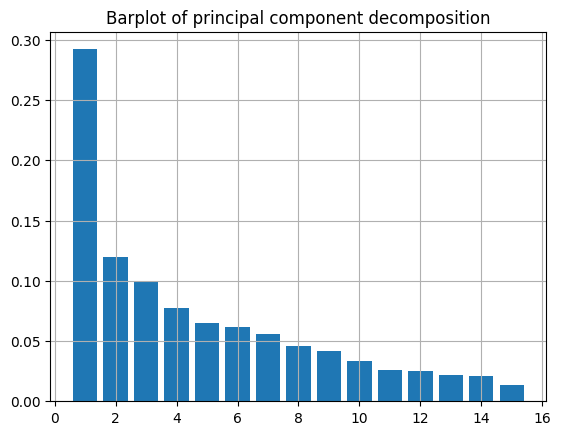

PC7 alone: 5.55% | Total with 7 PCs: 77.15%
PC8 alone: 4.58% | Total with 8 PCs: 81.74%
PC9 alone: 4.15% | Total with 9 PCs: 85.88%
PC10 alone: 3.35% | Total with 10 PCs: 89.23%
PC11 alone: 2.60% | Total with 11 PCs: 91.83%
PC12 alone: 2.53% | Total with 12 PCs: 94.35%


In [20]:
from project_utils import inertia_barplot
inertia_barplot(pca)

# Individual percentages
pc7_val = pca.explained_variance_ratio_[6] * 100
pc8_val = pca.explained_variance_ratio_[7] * 100
pc9_val = pca.explained_variance_ratio_[8] * 100
pc10_val = pca.explained_variance_ratio_[9] * 100
pc11_val = pca.explained_variance_ratio_[10] * 100
pc12_val = pca.explained_variance_ratio_[11] * 100

# Cumulative sums (The "Total Knowledge")
total_7 = sum(pca.explained_variance_ratio_[:7]) * 100
total_8 = sum(pca.explained_variance_ratio_[:8]) * 100
total_9 = sum(pca.explained_variance_ratio_[:9]) * 100
total_10 = sum(pca.explained_variance_ratio_[:10]) * 100
total_11 = sum(pca.explained_variance_ratio_[:11]) * 100
total_12 = sum(pca.explained_variance_ratio_[:12]) * 100

print(f"PC7 alone: {pc7_val:.2f}% | Total with 7 PCs: {total_7:.2f}%")
print(f"PC8 alone: {pc8_val:.2f}% | Total with 8 PCs: {total_8:.2f}%")
print(f"PC9 alone: {pc9_val:.2f}% | Total with 9 PCs: {total_9:.2f}%")
print(f"PC10 alone: {pc10_val:.2f}% | Total with 10 PCs: {total_10:.2f}%")
print(f"PC11 alone: {pc11_val:.2f}% | Total with 11 PCs: {total_11:.2f}%")
print(f"PC12 alone: {pc12_val:.2f}% | Total with 12 PCs: {total_12:.2f}%")

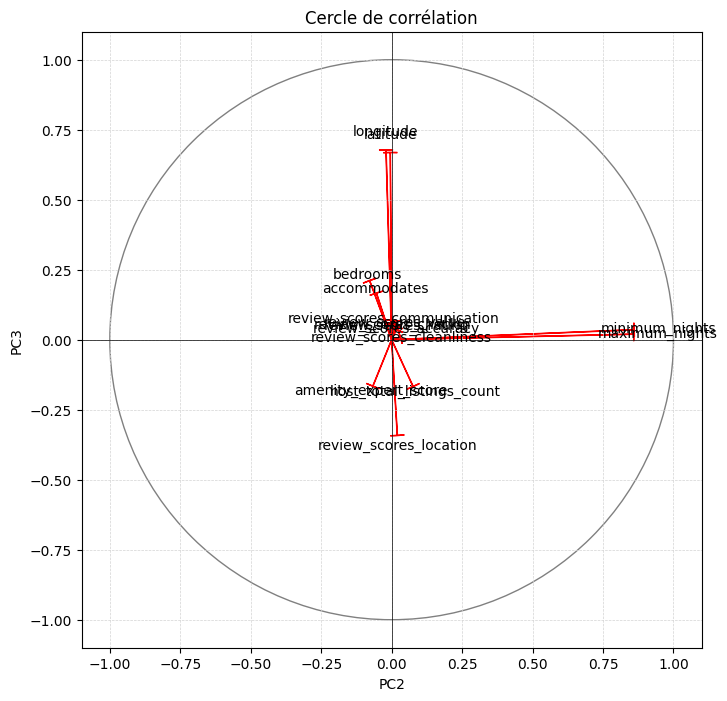

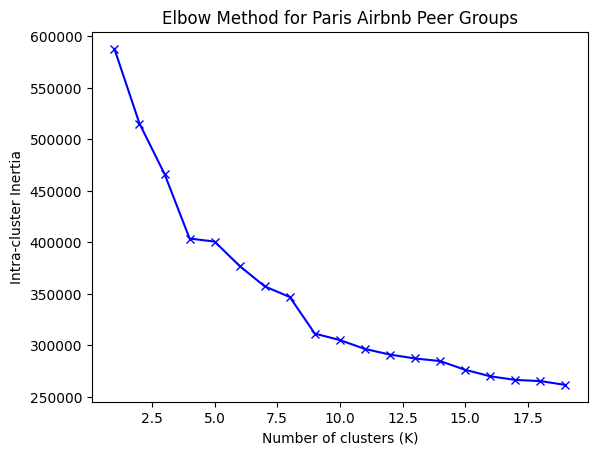

In [21]:
from project_utils import elbow_analysis, plot_correlation_circle

pca = PCA(n_components=8)
X_pca = pca.fit_transform(X_scaled)

c1 = 2
c2 = 3
plot_correlation_circle(X_scaled, X_pca, cluster_features, c1=c1, c2=c2)

#X_scaled = X_pca

elbow_analysis(X_pca, K=20)

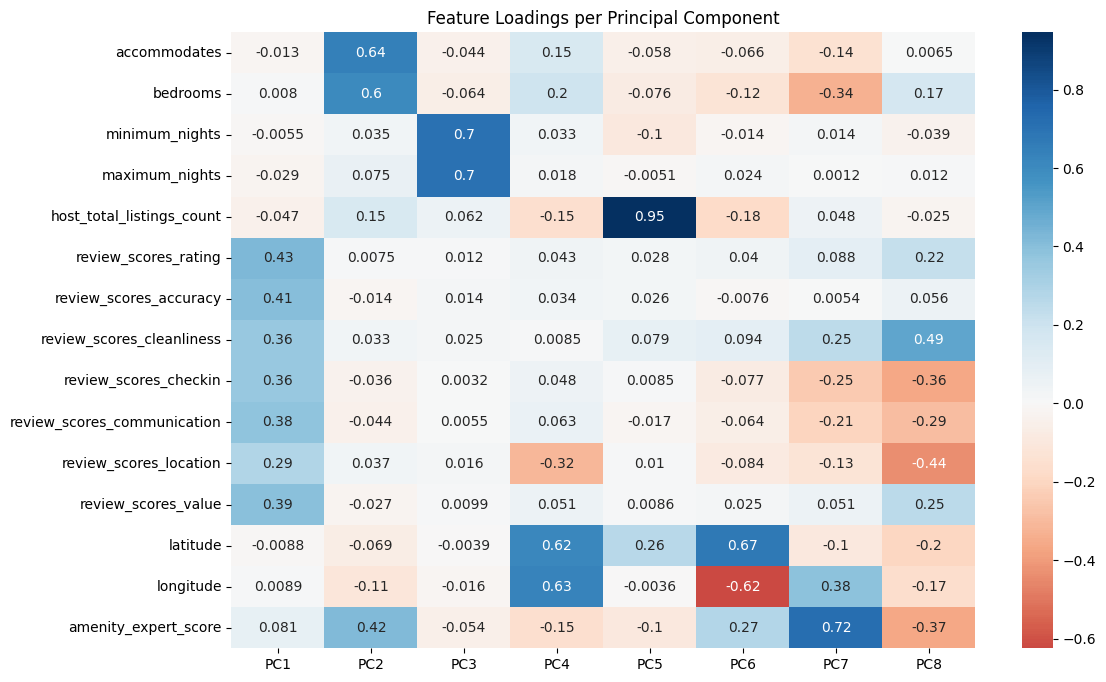

In [22]:
# 1. Access the loadings (components_) from your PCA object
# These represent the weights of each feature for each PC
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=cluster_features
)

# 2. Plot as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(loadings, annot=True, cmap='RdBu', center=0)
plt.title("Feature Loadings per Principal Component")
plt.show()

We can see in the elbow plot ....

We chose K=10 for good granularity

In [23]:
from sklearn.cluster import MiniBatchKMeans

# Fit the final model
kmeans_final = MiniBatchKMeans(n_clusters=9, random_state=42, batch_size=1024)
df_cleaned['cluster_id'] = kmeans_final.fit_predict(X_pca) # X is your normalized data

In [24]:
# Calculate mean and std price for each peer group
cluster_stats = df_cleaned.groupby('cluster_id')['price'].agg(['mean', 'std']).reset_index()
cluster_stats.columns = ['cluster_id', 'avg_price', 'std_price']

# Merge these stats back to the main dataframe
df_cleaned = df_cleaned.merge(cluster_stats, on='cluster_id')

In [25]:
# Sensitivity parameter
sensitivity = 0.3

# Calculate Robust Statistics for each cluster (as before)
cluster_robust_stats = df_cleaned.groupby('cluster_id')['price'].quantile([0.25, 0.75]).unstack()
cluster_robust_stats.columns = ['q1_price', 'q3_price']
cluster_robust_stats['iqr_price'] = cluster_robust_stats['q3_price'] - cluster_robust_stats['q1_price']
cluster_robust_stats['gem_threshold'] = cluster_robust_stats['q1_price'] - (sensitivity * cluster_robust_stats['iqr_price'])

# Remove any old threshold or is_gem columns if they exist
cols_to_remove = [c for c in df_cleaned.columns if 'gem_threshold' in c or 'is_gem' in c]
df_cleaned = df_cleaned.drop(columns=cols_to_remove)

# Merge back to the main dataframe safely
# We reset_index on cluster_robust_stats because 'cluster_id' is currently its index
df_cleaned = df_cleaned.merge(cluster_robust_stats[['gem_threshold']], on='cluster_id')

# Apply the final Label
df_cleaned['is_gem'] = (df_cleaned['price'] < df_cleaned['gem_threshold']).astype(int)

# Check the distribution
print(df_cleaned['is_gem'].value_counts(normalize=True))

is_gem
0    0.902609
1    0.097391
Name: proportion, dtype: float64


Missing Latitude: 0
Missing Longitude: 0
Plotting 47941 points...


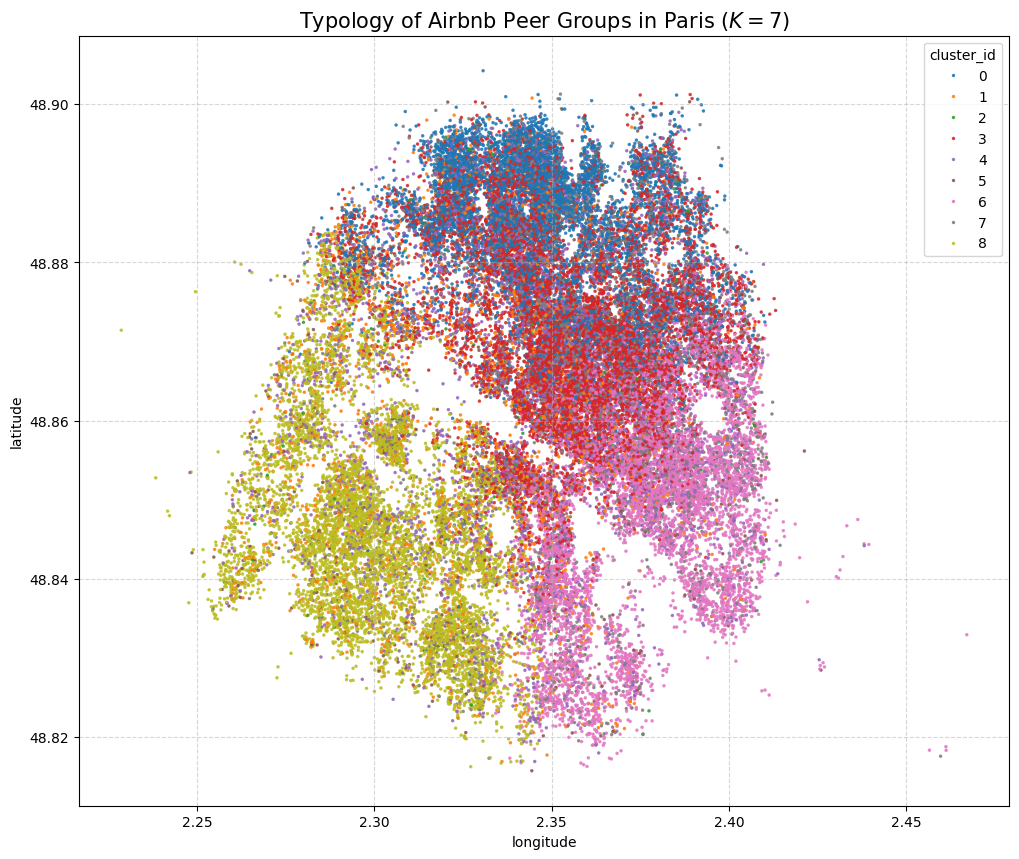

In [26]:
# Check if there are NaNs in the coordinates first
print("Missing Latitude:", df_cleaned['latitude'].isnull().sum())
print("Missing Longitude:", df_cleaned['longitude'].isnull().sum())

print(f"Plotting {len(df_cleaned)} points...")

plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=df_cleaned, 
    x='longitude',    
    y='latitude',      
    hue='cluster_id', 
    palette='tab10',
    s=5,              
    alpha=0.9, 
    edgecolor=None
)

plt.title("Typology of Airbnb Peer Groups in Paris ($K=7$)", fontsize=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [41]:
# Create a typology table using Medians (Robust to outliers)
typology = df_cleaned.groupby('cluster_id')[features + ['amenity_expert_score']].median()

# Add a count to see how big each group is
typology['count'] = df_cleaned.groupby('cluster_id').size()

# Sort by rating to find the "Bad" cluster immediately
print(typology[features + ['amenity_expert_score'] + ['count']].sort_values(by='review_scores_rating'))

            price  accommodates  bedrooms  minimum_nights  maximum_nights  \
cluster_id                                                                  
2            84.0           2.0       1.0             2.0          1125.0   
5            78.0           3.0       1.0             2.0          1125.0   
7            60.0           2.0       1.0             2.0          1125.0   
1           105.0           4.0       1.0             2.0          1125.0   
6            70.0           2.0       1.0             2.0          1124.0   
0            60.0           2.0       1.0             2.0          1125.0   
4           175.0           6.0       2.0             3.0          1125.0   
8            80.0           2.0       1.0             2.0          1125.0   
3            85.0           2.0       1.0             3.0          1125.0   

            host_total_listings_count  review_scores_rating  \
cluster_id                                                    
2                         

In [28]:
# Calculate the percentage of gems in each cluster
gem_stats = df_cleaned.groupby('cluster_id')['is_gem'].mean() * 100
gem_stats = gem_stats.reset_index()
gem_stats.columns = ['cluster_id', 'gem_percentage']

# Sort by percentage to see where the "Value" is concentrated
print(gem_stats.sort_values(by='gem_percentage', ascending=False))

   cluster_id  gem_percentage
3           3       13.520926
0           0       11.858891
8           8       11.362980
6           6        8.107364
7           7        8.028632
5           5        7.795100
1           1        7.144660
2           2        6.593407
4           4        4.240791


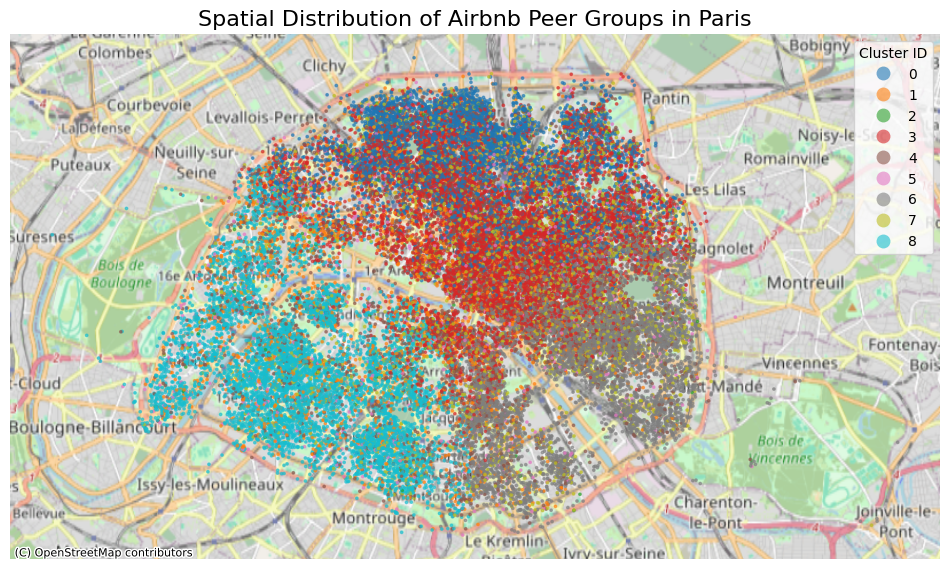

In [29]:
import geopandas as gpd
import contextily as ctx

# Convert df_paris to a GeoDataFrame
gdf = gpd.GeoDataFrame(
    df_cleaned, 
    geometry=gpd.points_from_xy(df_cleaned.longitude, df_cleaned.latitude),
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(12, 12))

gdf.plot(
    ax=ax,
    column='cluster_id', 
    categorical=True, 
    legend=True, 
    markersize=3,       # Keep points small so the map is visible
    alpha=0.6, 
    cmap='tab10',
    legend_kwds={'title': "Cluster ID", 'bbox_to_anchor': (1, 1)}
)

# Add the Paris background map
ctx.add_basemap(ax, crs=gdf.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off() 
plt.title("Spatial Distribution of Airbnb Peer Groups in Paris", fontsize=16)
plt.show()

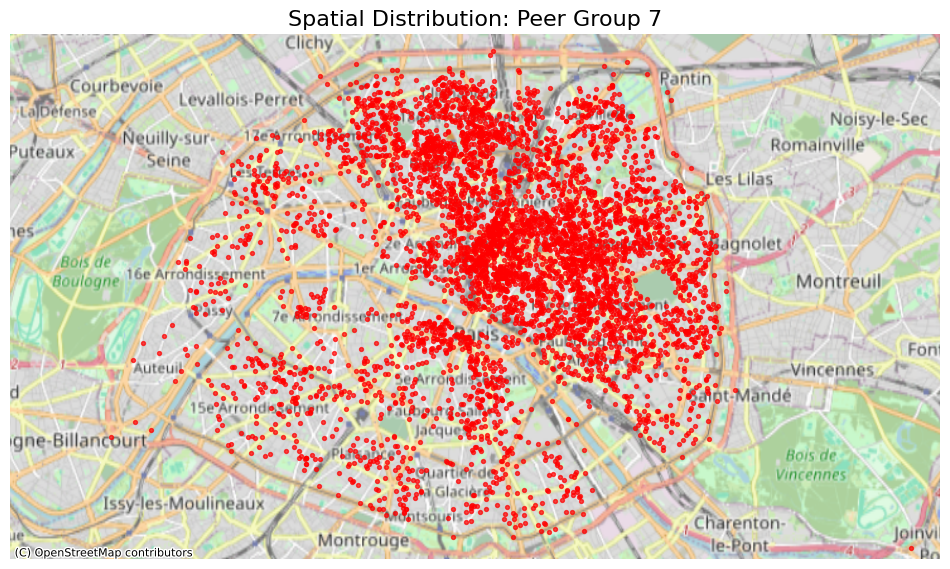

In [38]:
# Get the total bounds of Paris once so the map stays still
minx, miny, maxx, maxy = gdf.total_bounds

def plot_single_cluster(target_id):
    fig, ax = plt.subplots(figsize=(12, 12))
    
    # Filter for just one cluster
    cluster_data = gdf[gdf['cluster_id'] == target_id]
    
    cluster_data.plot(
        ax=ax,
        color='red',        # Use a bold color to make it stand out
        markersize=8,       # Larger markers since there are fewer points
        alpha=0.7
    )
    
    # Add basemap
    ctx.add_basemap(ax, crs=gdf.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
    
    # CRITICAL: Keep the same view of Paris for every plot
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    
    ax.set_axis_off()
    plt.title(f"Spatial Distribution: Peer Group {target_id}", fontsize=16)
    plt.show()

# Example: Just look at the 'Bad Deal' cluster
plot_single_cluster(7)

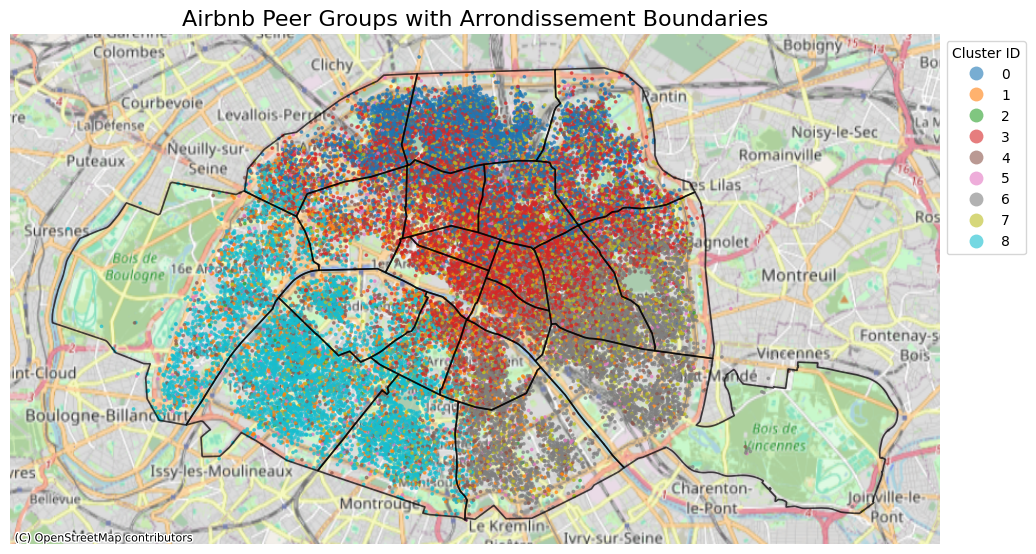

In [31]:
# 1. Fetch the arrondissement boundaries directly
districts_url = "https://opendata.paris.fr/explore/dataset/arrondissements/download/?format=geojson"
gdf_districts = gpd.read_file(districts_url)

# 2. Match the CRS to your points (CRITICAL for alignment)
gdf_districts = gdf_districts.to_crs(gdf.crs)

fig, ax = plt.subplots(figsize=(12, 12))

# 3. Plot the Airbnb points
gdf.plot(
    ax=ax,
    column='cluster_id', 
    categorical=True, 
    legend=True, 
    markersize=3, 
    alpha=0.6, 
    cmap='tab10',
    zorder=2, # Keep points on top of the lines
    legend_kwds={'title': "Cluster ID", 'bbox_to_anchor': (1.1, 1)}
)

# 4. Plot ONLY the boundary lines (not filled shapes)
gdf_districts.boundary.plot(
    ax=ax, 
    color="black", 
    linewidth=1.2, 
    alpha=0.7, 
    zorder=3  # Put lines slightly above points so they are visible
)

# Add the Paris background map
ctx.add_basemap(ax, crs=gdf.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off() 
plt.title("Airbnb Peer Groups with Arrondissement Boundaries", fontsize=16)
plt.show()

In [51]:
# KNN clustering to find good deals
# 2. Set the target variable
y = df_cleaned['cluster_id']

# 3. Split the data (using stratify ensures every cluster is represented proportionally)
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Train the model
# n_neighbors=5 is a standard starting point, adjust if needed
knn = KNeighborsClassifier(n_neighbors=43)
knn.fit(X_train, y_train)

# 5. Evaluate to ensure it accurately predicts the clusters
y_pred = knn.predict(X_test)
print(f"Overall KNN Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))

Overall KNN Accuracy: 0.9398

              precision    recall  f1-score   support

           0       0.94      0.93      0.94      1537
           1       0.94      0.88      0.91       792
           2       1.00      0.89      0.94        36
           3       0.91      0.98      0.94      1969
           4       0.97      0.96      0.96      1113
           5       0.98      0.87      0.92       270
           6       0.94      0.93      0.93      1453
           7       0.93      0.94      0.93      1034
           8       0.96      0.95      0.96      1385

    accuracy                           0.94      9589
   macro avg       0.95      0.92      0.94      9589
weighted avg       0.94      0.94      0.94      9589



In [48]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# 1. Define the range of neighbors you want to test
# Using range(1, 31, 2) tests all odd numbers from 1 to 29
param_grid = {'n_neighbors': range(1, 101, 2)}

# 2. Initialize a blank KNN model
base_knn = KNeighborsClassifier()

# 3. Set up the Grid Search with 5-Fold Cross Validation
# n_jobs=-1 tells your computer to use all its processing cores to do it faster
grid_search = GridSearchCV(
    estimator=base_knn, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1 
)

# 4. Run the search on your 8-component training data from earlier
grid_search.fit(X_train, y_train)

# 5. Reveal the winner
print(f"The optimal number of neighbors is: {grid_search.best_params_['n_neighbors']}")
print(f"Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# You can now use the best model directly!
# best_knn_model = grid_search.best_estimator_

The optimal number of neighbors is: 43
Cross-Validation Accuracy: 0.9319


## **Supervised part of project**

In [2]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import statistics
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import project_utils
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, accuracy_score
import shap
from sklearn.inspection import PartialDependenceDisplay
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV

In [4]:
df=pd.read_csv('Listings.csv',encoding="latin1")

# Data pre-processing
from project_utils import features

# Ensure we only use paris listings
df_paris = df[df['city'] == 'Paris'].copy()

# Inlcude amenities for computing amenity score
df_cleaned = df_paris[features+['amenities']].dropna(subset=['review_scores_rating'])

# Impute 'bedrooms' and 'host_count' with the median
df_cleaned['bedrooms'] = df_cleaned['bedrooms'].fillna(df_cleaned['bedrooms'].median())
df_cleaned['host_total_listings_count'] = df_cleaned['host_total_listings_count'].fillna(df_cleaned['host_total_listings_count'].median())

# Uncomment to perform checks
# print(df_cleaned[features].isnull().sum())
df_cleaned = df_cleaned.dropna()
# print(len(df_cleaned))

/var/folders/rd/pqn4crp95cbb0zy1xkn347jh0000gn/T/ipykernel_56679/348450226.py:1: DtypeWarning: Columns (5,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('Listings.csv',encoding="latin1")


In [5]:
from project_utils import add_amenity_scores

add_amenity_scores(df_cleaned)

print(df_cleaned[['amenities', 'amenity_expert_score']].head())

# Add amenity score to dataframe
df_cleaned = df_cleaned.drop(columns=['amenities']).astype(float)

                                           amenities  amenity_expert_score
0  ["Heating", "Kitchen", "Washer", "Wifi", "Long...                    39
1  ["Shampoo", "Heating", "Kitchen", "Essentials"...                    52
2  ["Heating", "TV", "Kitchen", "Washer", "Wifi",...                    43
3  ["Heating", "TV", "Kitchen", "Wifi", "Long ter...                    35
4  ["Heating", "TV", "Kitchen", "Essentials", "Ha...                    75


In [6]:
df_cleaned=df_cleaned.astype(float)
print(df_cleaned.info())

<class 'pandas.core.frame.DataFrame'>
Index: 47941 entries, 0 to 279711
Data columns (total 59 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   price                           47941 non-null  float64
 1   accommodates                    47941 non-null  float64
 2   bedrooms                        47941 non-null  float64
 3   minimum_nights                  47941 non-null  float64
 4   maximum_nights                  47941 non-null  float64
 5   host_total_listings_count       47941 non-null  float64
 6   review_scores_rating            47941 non-null  float64
 7   review_scores_accuracy          47941 non-null  float64
 8   review_scores_cleanliness       47941 non-null  float64
 9   review_scores_checkin           47941 non-null  float64
 10  review_scores_communication     47941 non-null  float64
 11  review_scores_location          47941 non-null  float64
 12  review_scores_value             4794

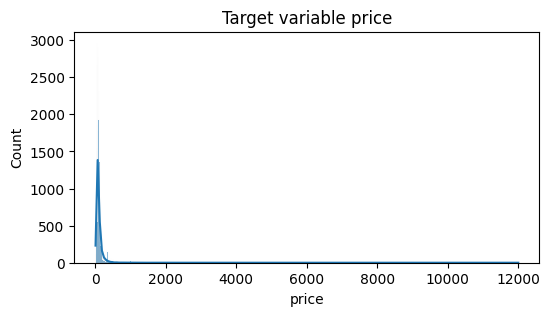

In [8]:
plt.figure(figsize=(6,3))
sns.histplot(df_cleaned["price"], kde=True)
plt.title('Target variable price')
plt.show()

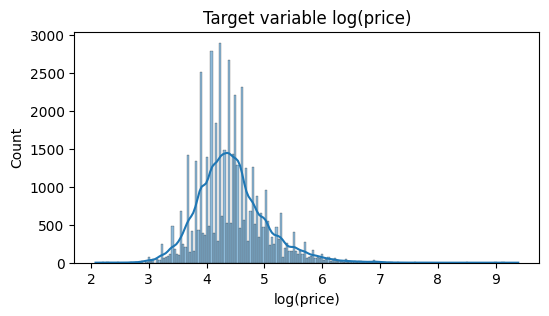

In [9]:
df_cleaned["log_price"] = np.log(df_cleaned["price"])
plt.figure(figsize=(6,3))
sns.histplot(df_cleaned["log_price"], kde=True)
plt.xlabel('log(price)')
plt.title('Target variable log(price)')
plt.show()

In [10]:

X=df_cleaned.drop(columns=['price','log_price'])
y=np.log(df_cleaned['price'])
#y.head()
#X.head()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV

lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LassoCV(
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

lasso_pipeline.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LassoCV(cv=5, max_iter=10000, random_state=42))])

In [11]:
from sklearn.metrics import mean_squared_error, r2_score
lasso_pred = lasso_pipeline.predict(X_test)

lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_r2 = r2_score(y_test, lasso_pred)
print('Lasso:')
print("RMSE:", lasso_rmse)
print("R²:", lasso_r2)

Lasso:
RMSE: 0.43547195706545283
R²: 0.45813255378772944


In [191]:
lasso_model = lasso_pipeline.named_steps["model"]
coef = lasso_model.coef_
selected_features = X.columns[coef != 0]
print('Number of selected features:', len(selected_features))

Number of selected features: 57


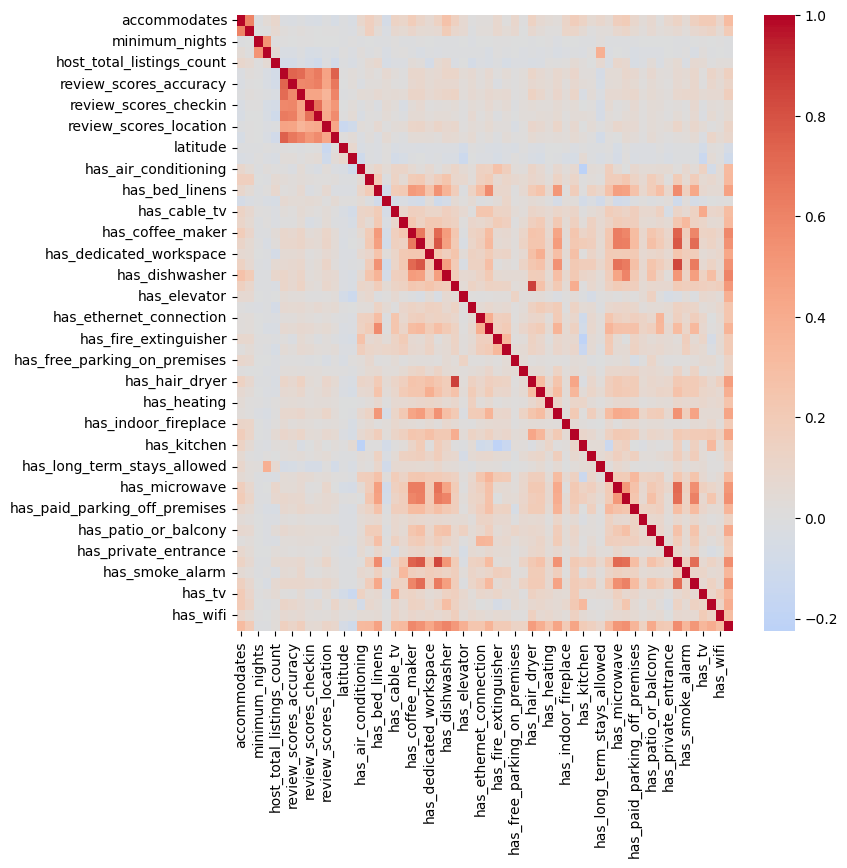

In [192]:
corr = X_train.corr()

plt.figure(figsize=(8,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.show()

# Elastic net

In [193]:

enet_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        cv=5,
        max_iter=20000
    ))
])

enet_pipeline.fit(X_train, y_train)
enet_pred = enet_pipeline.predict(X_test)

enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))
enet_r2 = r2_score(y_test, enet_pred)
print("Enet:")
print("RMSE:", enet_rmse)
print("R²:", enet_r2)

Enet:
RMSE: 0.43547205914457404
R²: 0.4581322997490558


# Ridge

In [194]:

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=np.logspace(-3, 3, 50)))
])

ridge_pipeline.fit(X_train, y_train)
ridge_pipeline.score(X_test, y_test)

ridge_pred = ridge_pipeline.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge:")
print("RMSE:", ridge_rmse)
print("R²:", ridge_r2)

Ridge:
RMSE: 0.4354855204321206
R²: 0.45809879886415805


# PCA regression

In [196]:

pca_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("reg", LinearRegression())
])

pca_model.fit(X_train, y_train)

pca_pred = pca_model.predict(X_test)

pca_rmse = np.sqrt(mean_squared_error(y_test, pca_pred))
pca_r2 = r2_score(y_test, pca_pred)

print('PCA:')
print("RMSE:", pca_rmse)
print("R²:", pca_r2)

PCA:
RMSE: 0.4398646404523191
R²: 0.447145590773639


# Nonlinear

In [12]:


rf_model = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", RandomForestRegressor())
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print('Random forest regressor')
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random forest regressor
RMSE: 0.38704611385886484
R²: 0.5719464561166149


# GBR

In [198]:


gbr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", GradientBoostingRegressor())
])

gbr_model.fit(X_train, y_train)

gbr_pred = gbr_model.predict(X_test)

gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_pred))
gbr_r2 = r2_score(y_test, gbr_pred)

print('Gradient Boosting regressor')
print("RMSE:", gbr_rmse)
print("R²:", gbr_r2)

Gradient Boosting regressor
RMSE: 0.3928985553701373
R²: 0.5589035745552001


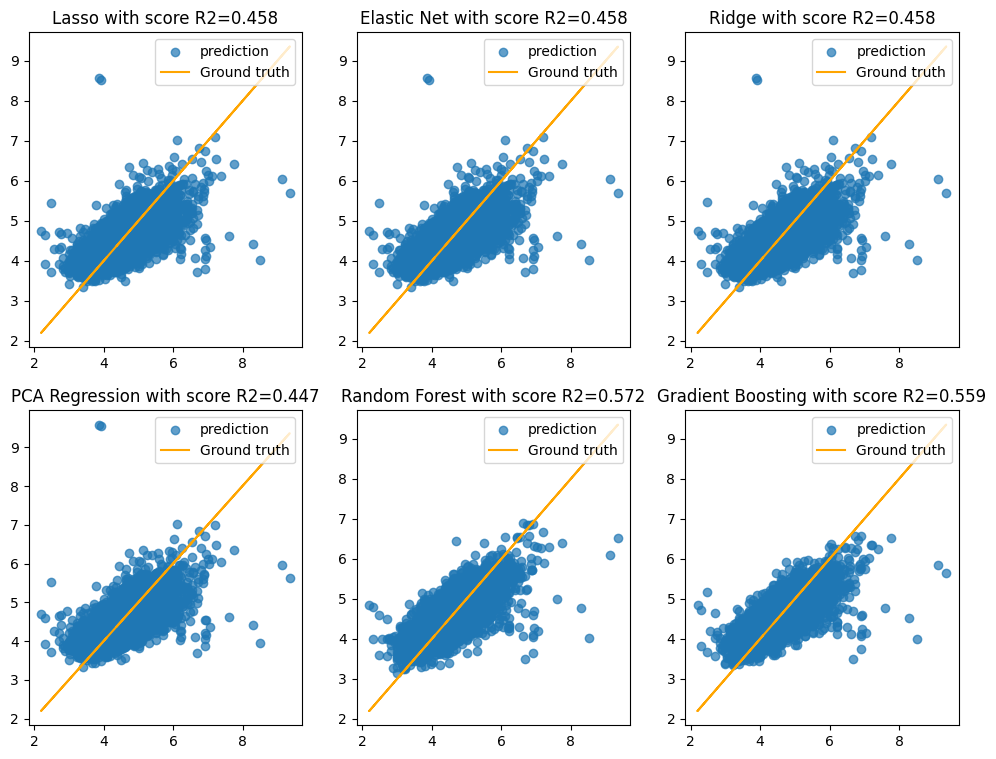

In [199]:
fig,axes=plt.subplots(2,3,figsize=(12,9))
axs=axes.ravel()
preds=[lasso_pred,enet_pred,ridge_pred,pca_pred,rf_pred,gbr_pred]
scores=[lasso_r2,enet_r2,ridge_r2,pca_r2,rf_r2,gbr_r2]
models=['Lasso','Elastic Net','Ridge','PCA Regression','Random Forest','Gradient Boosting']
for i in range(0,len(axs)):
    axs[i].scatter(y_test,preds[i],alpha=0.7,label='prediction')
    axs[i].plot(y_test,y_test,color='orange',label='Ground truth')
    axs[i].legend(loc='upper right')
    axs[i].set_title(f"{models[i]} with score R2={scores[i].round(3)}")

# Dataset without outliers

In [200]:
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = (y >= lower) & (y <= upper)

df_no_outliers = df_cleaned[mask].copy()

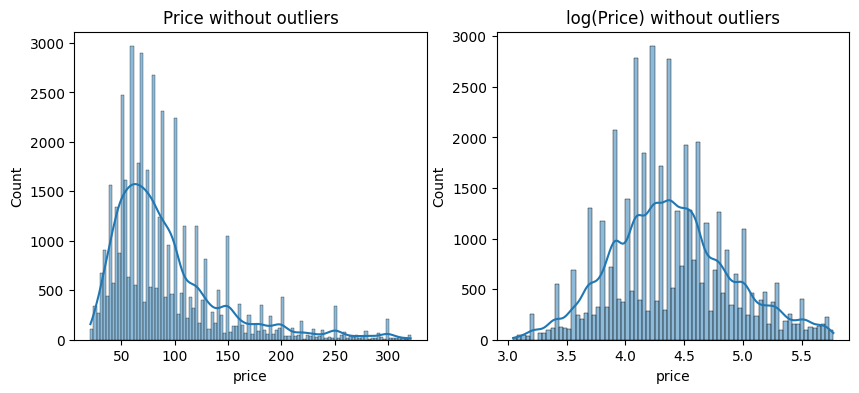

In [201]:
X=df_no_outliers.drop(columns=['price','log_price'])
y=np.log(df_no_outliers['price'])

fig,axs=plt.subplots(1,2,figsize=(10,4))
sns.histplot(df_no_outliers['price'],kde=True,ax=axs[0])
sns.histplot(np.log(df_no_outliers['price']),kde=True,ax=axs[1])
axs[0].set_title('Price without outliers')
axs[1].set_title('log(Price) without outliers')
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

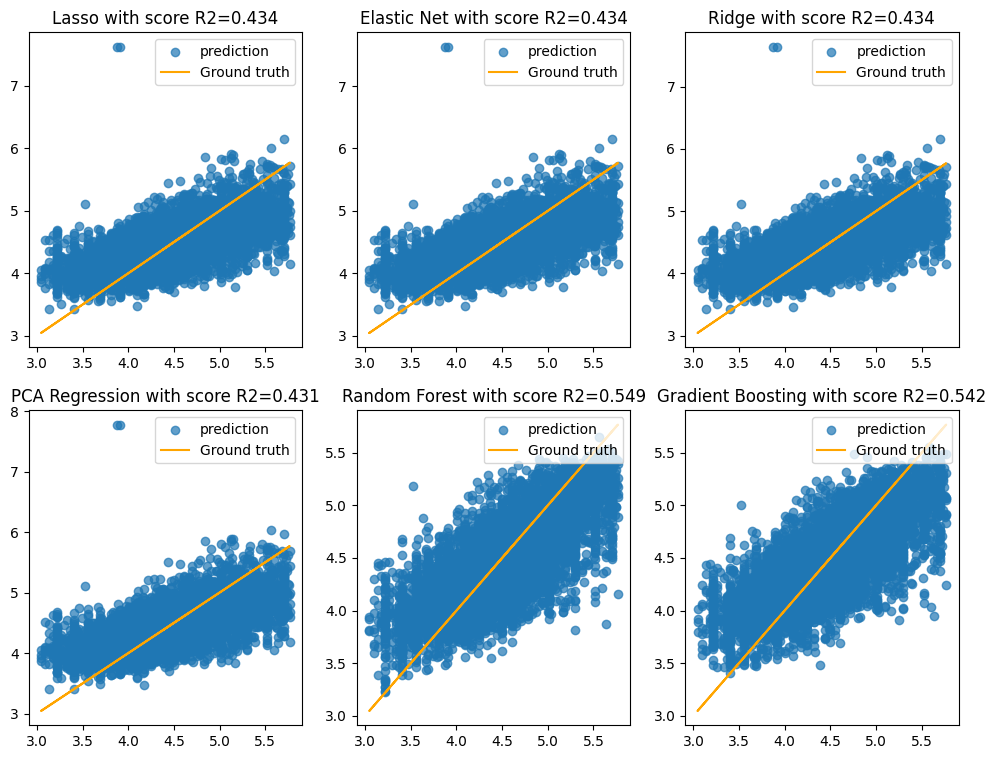

In [202]:
##LASSO
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LassoCV(
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])
lasso_pipeline.fit(X_train,y_train)
lasso_pred = lasso_pipeline.predict(X_test)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_r2 = r2_score(y_test, lasso_pred)
##ENET
enet_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        cv=5,
        max_iter=20000
    ))
])
enet_pipeline.fit(X_train, y_train)
enet_pred = enet_pipeline.predict(X_test)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))
enet_r2 = r2_score(y_test, enet_pred)
##RIDGE
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=np.logspace(-3, 3, 50)))
])
ridge_pipeline.fit(X_train, y_train)
ridge_pred = ridge_pipeline.predict(X_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)
#PCA
pca_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("reg", LinearRegression())
])
pca_model.fit(X_train, y_train)
pca_pred = pca_model.predict(X_test)
pca_rmse = np.sqrt(mean_squared_error(y_test, pca_pred))
pca_r2 = r2_score(y_test, pca_pred)
#RANDOM FOREST
rf_model = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", RandomForestRegressor())
])
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

gbr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", GradientBoostingRegressor())
])
gbr_model.fit(X_train, y_train)
gbr_pred = gbr_model.predict(X_test)
gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_pred))
gbr_r2 = r2_score(y_test, gbr_pred)

fig,axes=plt.subplots(2,3,figsize=(12,9))
axs=axes.ravel()
preds=[lasso_pred,enet_pred,ridge_pred,pca_pred,rf_pred,gbr_pred]
scores=[lasso_r2,enet_r2,ridge_r2,pca_r2,rf_r2,gbr_r2]
models=['Lasso','Elastic Net','Ridge','PCA Regression','Random Forest','Gradient Boosting']
for i in range(0,len(axs)):
    axs[i].scatter(y_test,preds[i],alpha=0.7,label='prediction')
    axs[i].plot(y_test,y_test,color='orange',label='Ground truth')
    axs[i].legend(loc='upper right')
    axs[i].set_title(f"{models[i]} with score R2={scores[i].round(3)}")

As we can see, from the distribution of the price variable, gives us a clean right-skewed distribution of price and a symmetric distribution of log(price). However, the regression models does not perform better which tells us that it is not a limiting factor of the regression. As we have higher r2 score for Random Forest and Gradient Boosting, we clearly have some nonlinear relationships in the dataset. We can conclude that the tail of the distribution contains information, information that when removed hurts generalisation.

# Mutual information 

In [210]:
df_cleaned["accommodates"] = np.log1p(df_cleaned["accommodates"])
df_cleaned["bedrooms"] = np.log1p(df_cleaned["bedrooms"])

X=df_cleaned.drop(columns=['price','log_price'])
y=np.log(df_cleaned['price'])


In [211]:

mi = mutual_info_regression(X, y)

mi_scores = pd.Series(mi, index=X.columns)
mi_scores.sort_values(ascending=False).head(15)

accommodates                 0.220871
bedrooms                     0.169123
amenity_expert_score         0.118304
host_total_listings_count    0.109059
has_dishwasher               0.064149
longitude                    0.053340
has_tv                       0.050280
minimum_nights               0.045572
latitude                     0.040659
has_coffee_maker             0.036462
has_dryer                    0.032162
has_hair_dryer               0.030251
has_cable_tv                 0.029471
has_bed_linens               0.028909
has_oven                     0.028803
dtype: float64

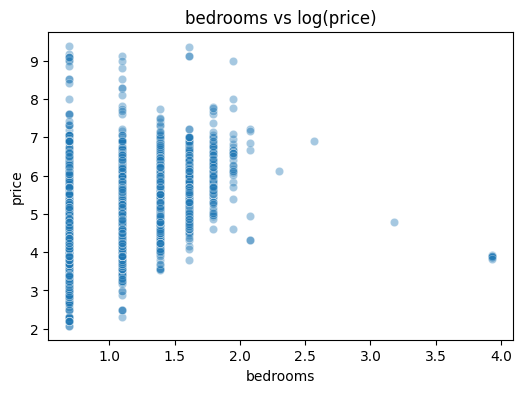

In [215]:
feature = X.columns[1]  # replace with important feature

plt.figure(figsize=(6,4))
sns.scatterplot(x=X[feature], y=y, alpha=0.4)
plt.title(f"{feature} vs log(price)")
plt.show()


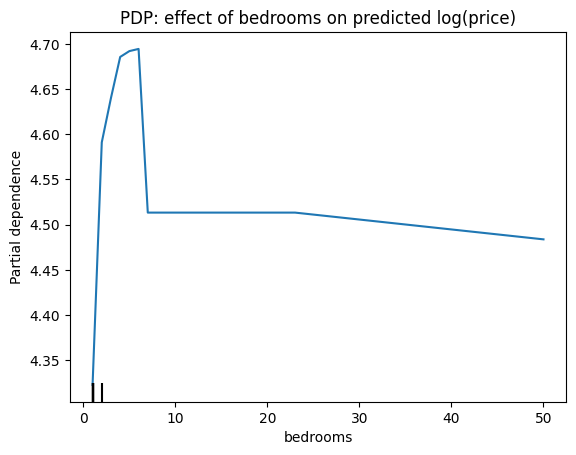

In [216]:

PartialDependenceDisplay.from_estimator(
    rf_model,
    X_train,
    [feature],
    grid_resolution=50
)

plt.title("PDP: effect of bedrooms on predicted log(price)")
plt.show()